Computing A(Om) and z_c(Om)...
  [ 1/30]  Om=0.1800  A=3.3543  z_c=0.4248
  [ 2/30]  Om=0.1876  A=3.3771  z_c=0.4207
  [ 3/30]  Om=0.1952  A=3.3991  z_c=0.4168
  [ 4/30]  Om=0.2028  A=3.4205  z_c=0.4131
  [ 5/30]  Om=0.2103  A=3.4414  z_c=0.4096
  [ 6/30]  Om=0.2179  A=3.4616  z_c=0.4062
  [ 7/30]  Om=0.2255  A=3.4814  z_c=0.4030
  [ 8/30]  Om=0.2331  A=3.5006  z_c=0.3999
  [ 9/30]  Om=0.2407  A=3.5194  z_c=0.3969
  [10/30]  Om=0.2483  A=3.5377  z_c=0.3941
  [11/30]  Om=0.2559  A=3.5557  z_c=0.3913
  [12/30]  Om=0.2634  A=3.5732  z_c=0.3886
  [13/30]  Om=0.2710  A=3.5903  z_c=0.3861
  [14/30]  Om=0.2786  A=3.6071  z_c=0.3836
  [15/30]  Om=0.2862  A=3.6235  z_c=0.3812
  [16/30]  Om=0.2938  A=3.6396  z_c=0.3788
  [17/30]  Om=0.3014  A=3.6554  z_c=0.3766
  [18/30]  Om=0.3090  A=3.6708  z_c=0.3744
  [19/30]  Om=0.3166  A=3.6860  z_c=0.3723
  [20/30]  Om=0.3241  A=3.7009  z_c=0.3702
  [21/30]  Om=0.3317  A=3.7156  z_c=0.3682
  [22/30]  Om=0.3393  A=3.7299  z_c=0.3663
  [23/30]  Om=0.3469  A

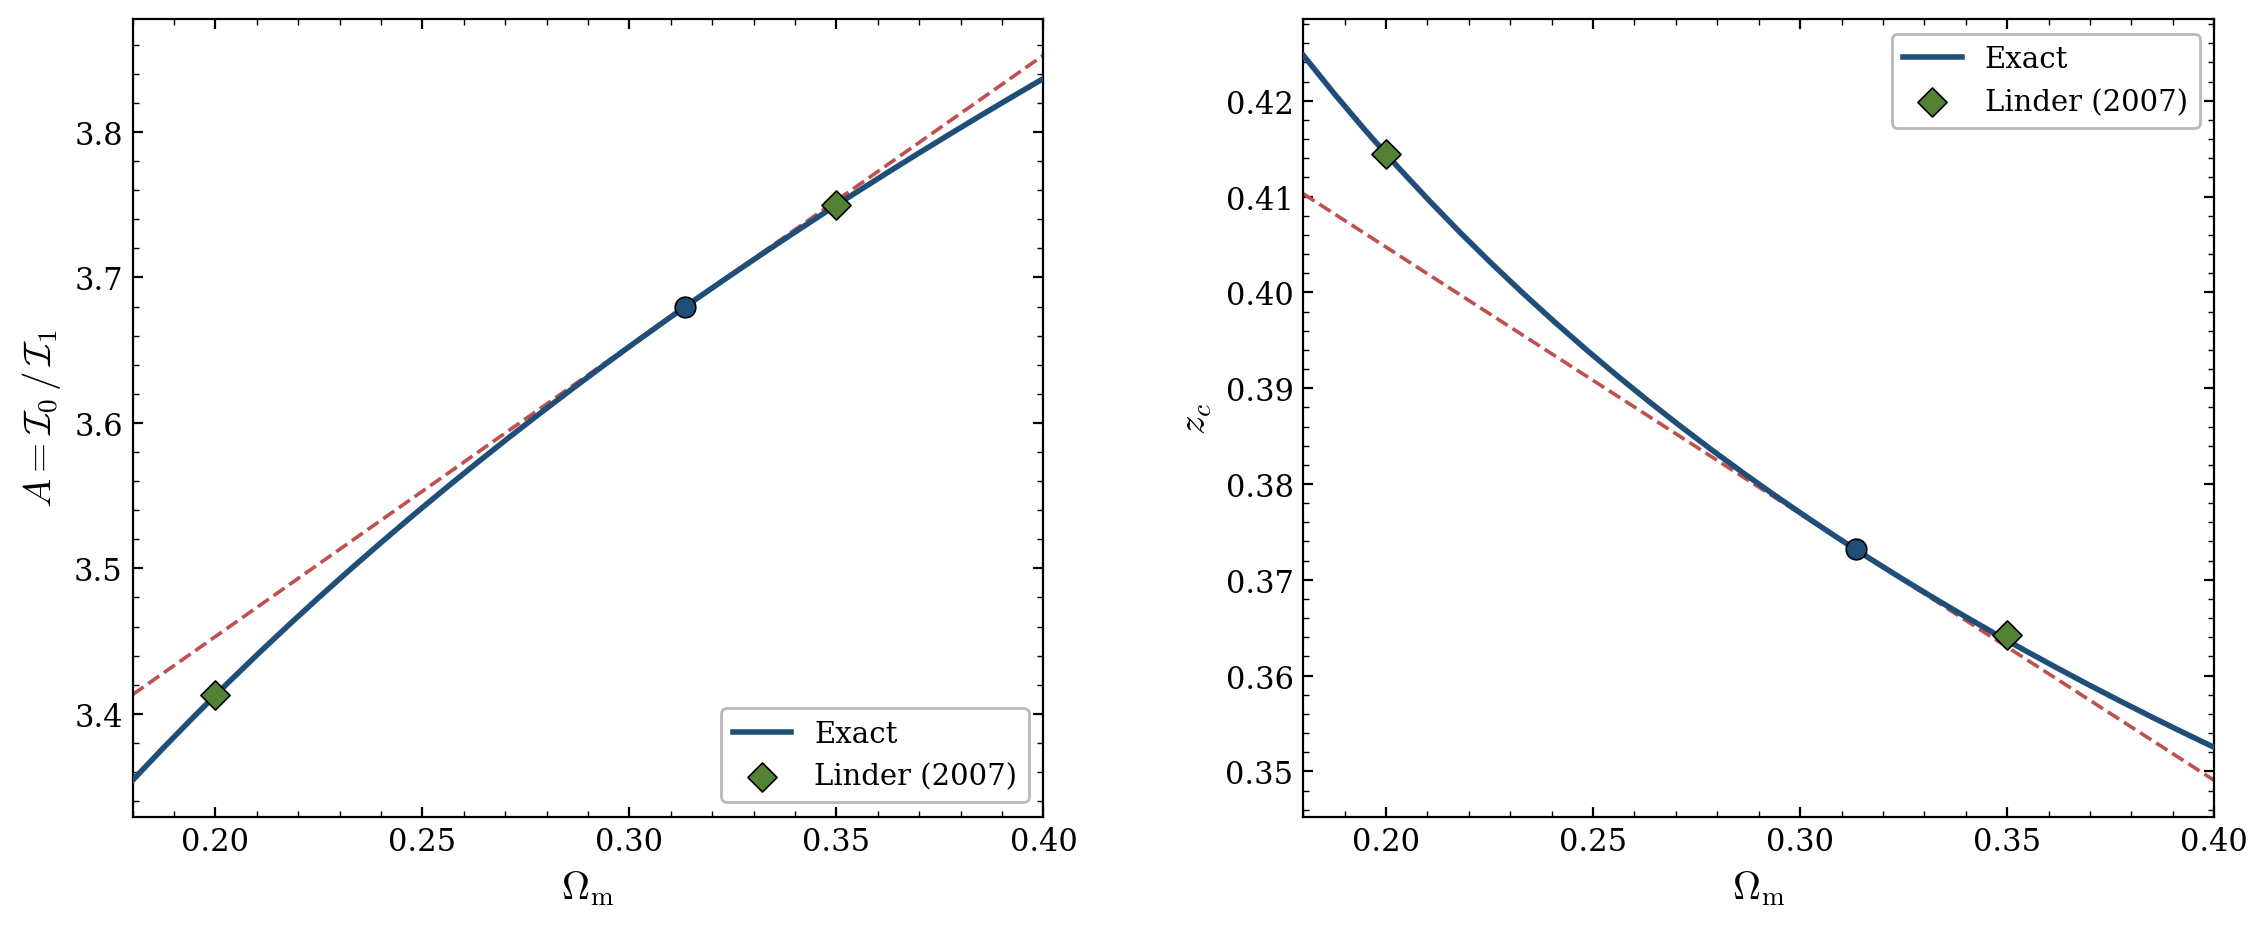

Done.


In [5]:
"""
Crossover Redshift Sensitivity to Omega_m
==========================================
"""

# Import libraries
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib

# Plot params
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'CMU Serif', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10.5,
    'figure.dpi': 200,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
})

# ══════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════

Z_STAR   = 1089.0
OM_FID   = 0.3134          
SIGMA_OM = 0.0073          

# Linder (2007) range :
# "If we change Om from 0.2 to 0.35 then a_w ranges from 0.707 to 0.733"
OM_LINDER_RANGE = np.array([0.20, 0.35])
AW_LINDER_RANGE = np.array([0.707, 0.733])

OM_MIN, OM_MAX, N_GRID = 0.18, 0.40, 30

# ══════════════════════════════════════════════════════════════════════
# INTEGRANDS 
# ══════════════════════════════════════════════════════════════════════

def E(z, Om):
    return np.sqrt(Om*(1+z)**3 + 1 - Om)

def J_inner(zp, Om):
    val, _ = quad(lambda z: E(z, Om)**-3, zp, Z_STAR, limit=200)
    return val

def L_inner(zp, Om):
    val, _ = quad(lambda z: ((1+z)**3 - 1) / E(z, Om)**5, zp, Z_STAR, limit=200)
    return val

def compute_I0(Om):
    val, _ = quad(lambda z: J_inner(z, Om)/(1+z), 0, Z_STAR, limit=200)
    return 1.5*(1-Om)*val

def compute_I1(Om):
    val, _ = quad(lambda z: z*J_inner(z, Om)/(1+z)**2, 0, Z_STAR, limit=200)
    return 1.5*(1-Om)*val

def compute_L0(Om):
    val, _ = quad(lambda z: L_inner(z, Om)/(1+z), 0, Z_STAR, limit=200)
    return val

def compute_L1(Om):
    val, _ = quad(lambda z: z*L_inner(z, Om)/(1+z)**2, 0, Z_STAR, limit=200)
    return val

def compute_all(Om):
    I0, I1 = compute_I0(Om), compute_I1(Om)
    L0, L1 = compute_L0(Om), compute_L1(Om)
    A  = I0/I1
    zc = I1/(I0 - I1)
    bracket = I0*L1 - I1*L0
    dA_dOm  =  9*(1-Om)/4 * bracket / I1**2
    dzc_dOm =  9*(1-Om)/4 * (-bracket) / (I0 - I1)**2
    return dict(I0=I0, I1=I1, L0=L0, L1=L1,
                A=A, zc=zc, ac=1/(1+zc),
                dA_dOm=dA_dOm, dzc_dOm=dzc_dOm)

# ══════════════════════════════════════════════════════════════════════
# GRID COMPUTATION
# ══════════════════════════════════════════════════════════════════════

Om_grid = np.linspace(OM_MIN, OM_MAX, N_GRID)
A_grid  = np.zeros(N_GRID)
zc_grid = np.zeros(N_GRID)

print("Computing A(Om) and z_c(Om)...")
for i, Om in enumerate(Om_grid):
    I0, I1 = compute_I0(Om), compute_I1(Om)
    A_grid[i]  = I0/I1
    zc_grid[i] = I1/(I0 - I1)
    print(f"  [{i+1:2d}/{N_GRID}]  Om={Om:.4f}  A={A_grid[i]:.4f}  z_c={zc_grid[i]:.4f}")

# Fiducial evaluation + derivatives
fid = compute_all(OM_FID)
print(f"\nFiducial (Om={OM_FID}):")
print(f"  A = {fid['A']:.4f},  z_c = {fid['zc']:.4f},  a_c = {fid['ac']:.4f}")
print(f"  dA/dOm = {fid['dA_dOm']:+.4f},  dz_c/dOm = {fid['dzc_dOm']:+.4f}")
print(f"  sigma(z_c) = {abs(fid['dzc_dOm'])*SIGMA_OM:.5f}")

# Linear approximation lines (through fiducial)
A_linear  = fid['A']  + fid['dA_dOm']  * (Om_grid - OM_FID)
zc_linear = fid['zc'] + fid['dzc_dOm'] * (Om_grid - OM_FID)

# Linder range points
zc_linder = 1.0/AW_LINDER_RANGE - 1.0
A_linder  = np.array([compute_I0(om)/compute_I1(om) for om in OM_LINDER_RANGE])

# ══════════════════════════════════════════════════════════════════════
# PLOT
# ══════════════════════════════════════════════════════════════════════

c_curve  = '#1f4e79'
c_linear = '#c0504d'
c_planck = '#4472C4'
c_linder = '#548235'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.8))

# ── LEFT: A vs Om ─────────────────────────────────────────────────
ax1.plot(Om_grid, A_grid, color=c_curve, lw=2.0, label='Exact', zorder=3)
ax1.plot(Om_grid, A_linear, color=c_linear, lw=1.3, ls='--', zorder=2)  # no label
ax1.scatter([OM_FID], [fid['A']], color=c_curve, s=55, zorder=5,
            edgecolors='k', linewidths=0.6)                              # no label
ax1.scatter(OM_LINDER_RANGE, A_linder, marker='D', s=55,
            color=c_linder, edgecolors='k', lw=0.6, zorder=5,
            label='Linder (2007)')
#ax1.axvspan(OM_FID - SIGMA_OM, OM_FID + SIGMA_OM,
            #color=c_planck, alpha=0.13, zorder=0,
            #label=r'Planck 2018 $1\sigma$')

ax1.set_xlabel(r'$\Omega_{\mathrm{m}}$')
ax1.set_ylabel(r'$A = \mathcal{I}_0\,/\,\mathcal{I}_1$')
ax1.legend(loc='lower right', frameon=True, framealpha=0.92, edgecolor='0.7')
ax1.set_xlim(OM_MIN, OM_MAX)
ax1.xaxis.set_major_locator(MultipleLocator(0.05))
ax1.xaxis.set_minor_locator(MultipleLocator(0.01))

# ── RIGHT: z_c vs Om ──────────────────────────────────────────────
ax2.plot(Om_grid, zc_grid, color=c_curve, lw=2.0, label='Exact', zorder=3)
ax2.plot(Om_grid, zc_linear, color=c_linear, lw=1.3, ls='--', zorder=2)  # no label
ax2.scatter([OM_FID], [fid['zc']], color=c_curve, s=55, zorder=5,
            edgecolors='k', linewidths=0.6)                               # no label
ax2.scatter(OM_LINDER_RANGE, zc_linder, marker='D', s=55,
            color=c_linder, edgecolors='k', lw=0.6, zorder=5,
            label='Linder (2007)')
#ax2.axvspan(OM_FID - SIGMA_OM, OM_FID + SIGMA_OM,
           # color=c_planck, alpha=0.13, zorder=0,
           # label=r'Planck 2018 $1\sigma$')

ax2.set_xlabel(r'$\Omega_{\mathrm{m}}$')
ax2.set_ylabel(r'$z_c$')
ax2.legend(loc='upper right', frameon=True, framealpha=0.92, edgecolor='0.7')
ax2.set_xlim(OM_MIN, OM_MAX)
ax2.xaxis.set_major_locator(MultipleLocator(0.05))
ax2.xaxis.set_minor_locator(MultipleLocator(0.01))

fig.tight_layout(w_pad=3.0)
fig.savefig('mirage_Om_sensitivity_final.pdf')
fig.savefig('mirage_Om_sensitivity_final.png')
plt.show()
print("Done.")